(chap_aihc_time_series)=
# Time-Series Models for Healthcare
**Content creators:** [Abhishek](https://github.com/moturuab)

**From a prevalence baseline to temporal convolution, recurrent networks, and attention**

Healthcare time series are not just tables with more rows. The order, spacing, missingness, and availability of measurements determine what a model is allowed to learn. This tutorial predicts a simulated deterioration-like endpoint at the end of a 30-hour observation window and compares seven approaches under one evaluation protocol:

$$
\text{prevalence} \rightarrow \text{last value} \rightarrow \text{summaries}
\rightarrow \text{HGB} \rightarrow \text{CNN/LSTM/GRU/Transformer}.
$$

## At a glance

| Item | What we will do |
|---|---|
| **Question** | At hour 30, rank simulated patients by risk of a fictional deterioration-like endpoint |
| **Data** | 1,500 simulated patient trajectories; 30 hourly steps; five fictional measurements; informative temporal motifs and realistic gaps |
| **Model ladder** | Prevalence, last-value logistic regression, summary-feature logistic regression, histogram gradient boosting (HGB), temporal CNN, LSTM, GRU, Transformer |
| **Fair comparison** | Patient-level train/validation/test split; causal imputation; training-only scaling; early stopping and thresholds selected on validation only |
| **Expected difficulty** | Moderate discrimination with overlapping classes—not near-perfect benchmark results |
| **Runtime** | About 1–3 minutes on a Colab CPU; GPU optional |
| **Core route** | Sections 1–14 take about 30–35 minutes; later sections deepen interpretation |

### Learning objectives

After the tutorial, you should be able to:

1. define an index time, observation window, prediction horizon, and outcome window;
2. explain why a last-value model, engineered summaries, and a nonlinear tree model are essential sequence-model baselines;
3. compare temporal CNNs, LSTMs, GRUs, and Transformers in plain language;
4. implement leakage-safe forward filling and training-only scaling;
5. evaluate rankings, probabilities, and a validation-selected operating point; and
6. explain why a more sophisticated model may not win on a modest dataset.

:::{admonition} 30–35-minute core route
:class: tip
Follow Sections 1–14 in order. Spend about 5 minutes defining the timeline and task (Sections 1–3), 8 minutes generating and auditing the cohort (Sections 4–8), 10 minutes comparing feature and sequence models (Sections 9–12), and 8–10 minutes selecting thresholds and interpreting the locked test results (Sections 13–14). Long helper and training cells are collapsed but fully commented. Sections 15–21 are optional deep dives for uncertainty, operating curves, case review, and deployment context.
:::


## 1. Start with the prediction timeline

A time-series model is meaningful only after the timeline is precise. Our fictional task is:

- **Observation window:** hours 0–29 after a simulated admission.
- **Index time:** immediately after hour 29.
- **Features available:** measurements charted by the index time.
- **Outcome:** a simulated binary deterioration-like endpoint generated after the window.

A value recorded after the index time is future information even if it appears in the same database table. Outcome-derived codes, retrospective labels, future treatment, discharge summaries, and post-index missingness are common sources of leakage.


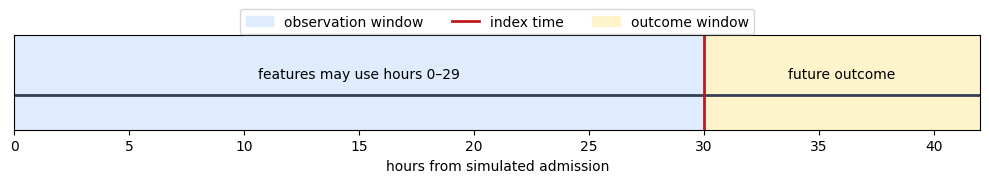

In [1]:
# A timeline makes the allowed information boundary visible.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2.2))
ax.hlines(0, 0, 42, color="#334155", linewidth=2)
ax.axvspan(0, 30, color="#dbeafe", alpha=0.9, label="observation window")
ax.axvline(30, color="#b91c1c", linewidth=2, label="index time")
ax.axvspan(30, 42, color="#fef3c7", alpha=0.9, label="outcome window")
ax.text(15, 0.10, "features may use hours 0–29", ha="center")
ax.text(36, 0.10, "future outcome", ha="center")
ax.set(xlim=(0, 42), ylim=(-0.2, 0.35), xlabel="hours from simulated admission")
ax.set_yticks([])
ax.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.35))
plt.tight_layout()
plt.show()


## 2. “Time series” includes several different tasks

Model choice depends on the question:

| Task | Example output | Typical methods |
|---|---|---|
| Sequence classification | one deterioration risk per window | feature models, CNN, RNN, Transformer |
| Sequence labelling | one state per time step | temporal CNN/RNN/Transformer with step-wise output |
| Forecasting | future measurement values | autoregression, state-space models, deep forecasting |
| Time-to-event modelling | risk over future time | Cox/survival models, discrete-time hazards, neural survival models |
| Irregular event modelling | risk from events at uneven times | time-aware RNNs, point processes, neural ODEs |

We study **sequence classification**. We do not claim that it is interchangeable with forecasting or survival analysis. The output is one risk score per patient window.


## 3. Why use simulated data here?

A teaching notebook needs data that can be distributed publicly, executes quickly, and has a completely known timeline. Real longitudinal health records are usually private, institution-specific, irregular, and governed by access agreements. Public ICU datasets are valuable but require credentialing, data-use training, substantial preprocessing, and careful cohort definitions—too much infrastructure for a 30-minute coding session.

Simulation lets us expose the generating logic: gradual changes, short early or late motifs, correlated noise, between-patient variation, and missing values. It also lets us demonstrate leakage by construction.

:::{admonition} Synthetic-results disclaimer
:class: warning
Every trajectory, label, and reported metric in this notebook is simulated. The numerical results do not describe patients, a hospital, a device, or an intervention. They cannot establish clinical accuracy, fairness, calibration, transportability, or benefit. The generator encodes our assumptions; a model may perform well simply because its architecture matches those assumptions.
:::

Importantly, simulation is the **intended dataset** for this conceptual session—not a hidden fallback. The endpoint remains uncertain because an unobserved factor affects it and labels are sampled probabilistically. That imposes a realistic ceiling and prevents the nearly perfect results that appear in overly clean demonstrations.


## 4. Reproducible setup

We use scikit-learn for feature-based models and PyTorch for sequence models. All models see the same patients and prediction window. We seed randomness and constrain CPU threads so the notebook is repeatable and Colab-friendly.


In [2]:
# Reproducibility utilities and neural-network state management.
import copy
import random

# Numerical arrays, tables, and plotting.
import numpy as np
import pandas as pd
import torch
from IPython.display import display
# Classical baselines and metrics used under the same patient split.
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
# PyTorch modules and mini-batch data containers for sequence learners.
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 41
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(2, torch.get_num_threads()))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}; training device: {DEVICE}")


ModuleNotFoundError: No module named 'torch._prims_common'

## 5. Generate a deliberately imperfect cohort

The generator has five fictional channels on familiar-looking scales: heart rate, respiratory rate, oxygen saturation, systolic blood pressure, and temperature. The names help interpretation, but the values are not sampled from real people.

Several mechanisms overlap:

1. **Between-patient variation:** people begin at different baselines.
2. **Autocorrelated noise:** adjacent hours resemble one another.
3. **Gradual trend:** channels can worsen or improve together.
4. **Short motif:** a four-hour multi-channel disturbance may occur early or late. Timing matters.
5. **Unobserved risk:** part of the endpoint cannot be inferred from the five channels.
6. **Probabilistic labels:** identical observed patterns need not have identical outcomes.
7. **Missing measurements:** gaps vary by patient and channel but do not directly use the future label.

This construction gives sequence models something genuine to learn while preserving overlap. The cell is collapsed because it is long; reveal it to audit every assumption.


In [ ]:
FEATURE_NAMES = ["heart_rate", "respiratory_rate", "spo2", "systolic_bp", "temperature"]
N_PATIENTS = 1_500
N_HOURS = 30


def generate_teaching_cohort(n_patients=N_PATIENTS, n_hours=N_HOURS, seed=SEED):
    '''Generate fictional trajectories with overlap, temporal motifs, and gaps.'''
    rng = np.random.default_rng(seed)
    hours = np.arange(n_hours, dtype=np.float32)
    centred_time = (hours - hours.mean()) / hours.std()

    # Familiar scales make plots readable; none of these rows is a real patient.
    typical_value = np.array([82.0, 18.0, 96.0, 118.0, 37.0], dtype=np.float32)
    between_patient_sd = np.array([9.0, 2.8, 1.1, 13.0, 0.35], dtype=np.float32)
    innovation_sd = np.array([3.8, 1.3, 0.55, 5.5, 0.16], dtype=np.float32)
    deterioration_direction = np.array([5.5, 2.1, -1.25, -7.5, 0.22], dtype=np.float32)

    # Patient-level latent variables affect several channels simultaneously.
    patient_offset = rng.normal(size=(n_patients, 5)).astype(np.float32) * between_patient_sd
    shared_severity = rng.normal(size=n_patients).astype(np.float32)
    gradual_trend = rng.normal(size=n_patients).astype(np.float32)
    volatility = rng.normal(size=n_patients).astype(np.float32)

    # Begin with each patient's baseline repeated over all 30 hours.
    complete_values = typical_value + patient_offset[:, None, :]
    complete_values = np.broadcast_to(complete_values, (n_patients, n_hours, 5)).copy()

    # AR(1) noise: 72% of the previous deviation carries into the next hour.
    # This makes neighbouring observations correlated instead of independent noise.
    ar_noise = np.zeros((n_patients, n_hours, 5), dtype=np.float32)
    innovations = rng.normal(size=(n_patients, n_hours, 5)).astype(np.float32)
    innovations *= innovation_sd
    for hour in range(1, n_hours):
        ar_noise[:, hour] = 0.72 * ar_noise[:, hour - 1] + innovations[:, hour]
    complete_values += ar_noise

    # A gradual latent trend moves channels in clinically intuitive but fictional directions.
    complete_values += (
        gradual_trend[:, None, None]
        * centred_time[None, :, None]
        * deterioration_direction[None, None, :]
        * 0.55
    )
    complete_values += (
        shared_severity[:, None, None]
        * deterioration_direction[None, None, :]
        * 0.22
    )

    # Half have no short motif; one quarter have an early motif; one quarter a late motif.
    # Early and late motifs have similar magnitudes, making timing—not just min/max—useful.
    motif_group = rng.choice(3, size=n_patients, p=[0.50, 0.25, 0.25])
    motif_amplitude = rng.uniform(0.65, 1.35, size=n_patients).astype(np.float32)
    motif_centres = np.where(motif_group == 1, 8.0, 24.0)
    motif = np.exp(-0.5 * ((hours[None, :] - motif_centres[:, None]) / 1.7) ** 2)
    motif *= (motif_group != 0)[:, None] * motif_amplitude[:, None]
    complete_values += motif[:, :, None] * deterioration_direction[None, None, :] * 1.05

    # Irregular perturbations stop trajectories from looking mechanically smooth.
    irregular_noise = np.abs(volatility)[:, None, None] * rng.normal(
        size=(n_patients, n_hours, 5)
    )
    complete_values += irregular_noise.astype(np.float32) * innovation_sd[None, None, :] * 0.35

    # The endpoint depends partly on visible signals and partly on an unobserved factor.
    # Sampling from this probability creates overlapping labels and an irreducible ceiling.
    unobserved_factor = rng.normal(scale=1.05, size=n_patients)
    log_odds = (
        -1.35
        + 0.34 * shared_severity
        + 0.38 * gradual_trend
        + 1.65 * (motif_group == 2)       # late motif increases risk
        - 0.55 * (motif_group == 1)       # early recovery-like motif lowers risk
        + 0.20 * np.maximum(volatility, 0)
        + 0.72 * ((gradual_trend > 0.45) & (volatility > 0.25))
        + unobserved_factor
    )
    latent_probability = 1.0 / (1.0 + np.exp(-log_odds))
    labels = rng.binomial(1, latent_probability).astype(np.int64)

    # Missingness varies by patient and channel. It never receives the future label.
    patient_missingness = rng.beta(2.0, 10.0, size=n_patients)[:, None, None]
    feature_missingness = np.array([0.05, 0.07, 0.10, 0.06, 0.13])[None, None, :]
    missing_probability = np.clip(patient_missingness + feature_missingness, 0, 0.48)
    observed_mask = rng.random((n_patients, n_hours, 5)) > missing_probability
    observed_mask[:, 0, :] = True  # guarantee a causal starting value for forward fill

    observed_values = complete_values.copy()
    observed_values[~observed_mask] = np.nan
    return observed_values, labels, latent_probability, motif_group


X_observed, y, latent_probability, motif_group = generate_teaching_cohort()
assert X_observed.shape == (N_PATIENTS, N_HOURS, len(FEATURE_NAMES))
assert set(np.unique(y)) == {0, 1}

print("Trajectory tensor shape:", X_observed.shape)
print(f"Overall simulated event prevalence: {y.mean():.3f}")
print(f"Missing entries: {np.isnan(X_observed).mean():.1%}")


Trajectory tensor shape: (1500, 30, 5)
Overall simulated event prevalence: 0.339
Missing entries: 23.6%


The prevalence should be substantial but far from 50%. That makes AUPRC interpretable: a constant ranking begins near the event fraction, and useful models should improve above it. The labels are not cleanly separable. Some event-positive trajectories look stable because of the unobserved factor; some event-negative trajectories contain concerning patterns but do not experience the sampled endpoint.

This ambiguity is not an error to remove. It is what makes the exercise closer to prediction than deterministic pattern recognition.


## 6. Inspect trajectories and missingness before modelling

We plot observed points only—lines do not bridge gaps—so missingness remains visible. To avoid cherry-picking, patient IDs are selected by a fixed rule: the first two negatives and first two positives in the generated cohort.


,missing_fraction
heart_rate,20.9%
respiratory_rate,22.5%
spo2,25.2%
systolic_bp,21.5%
temperature,27.8%


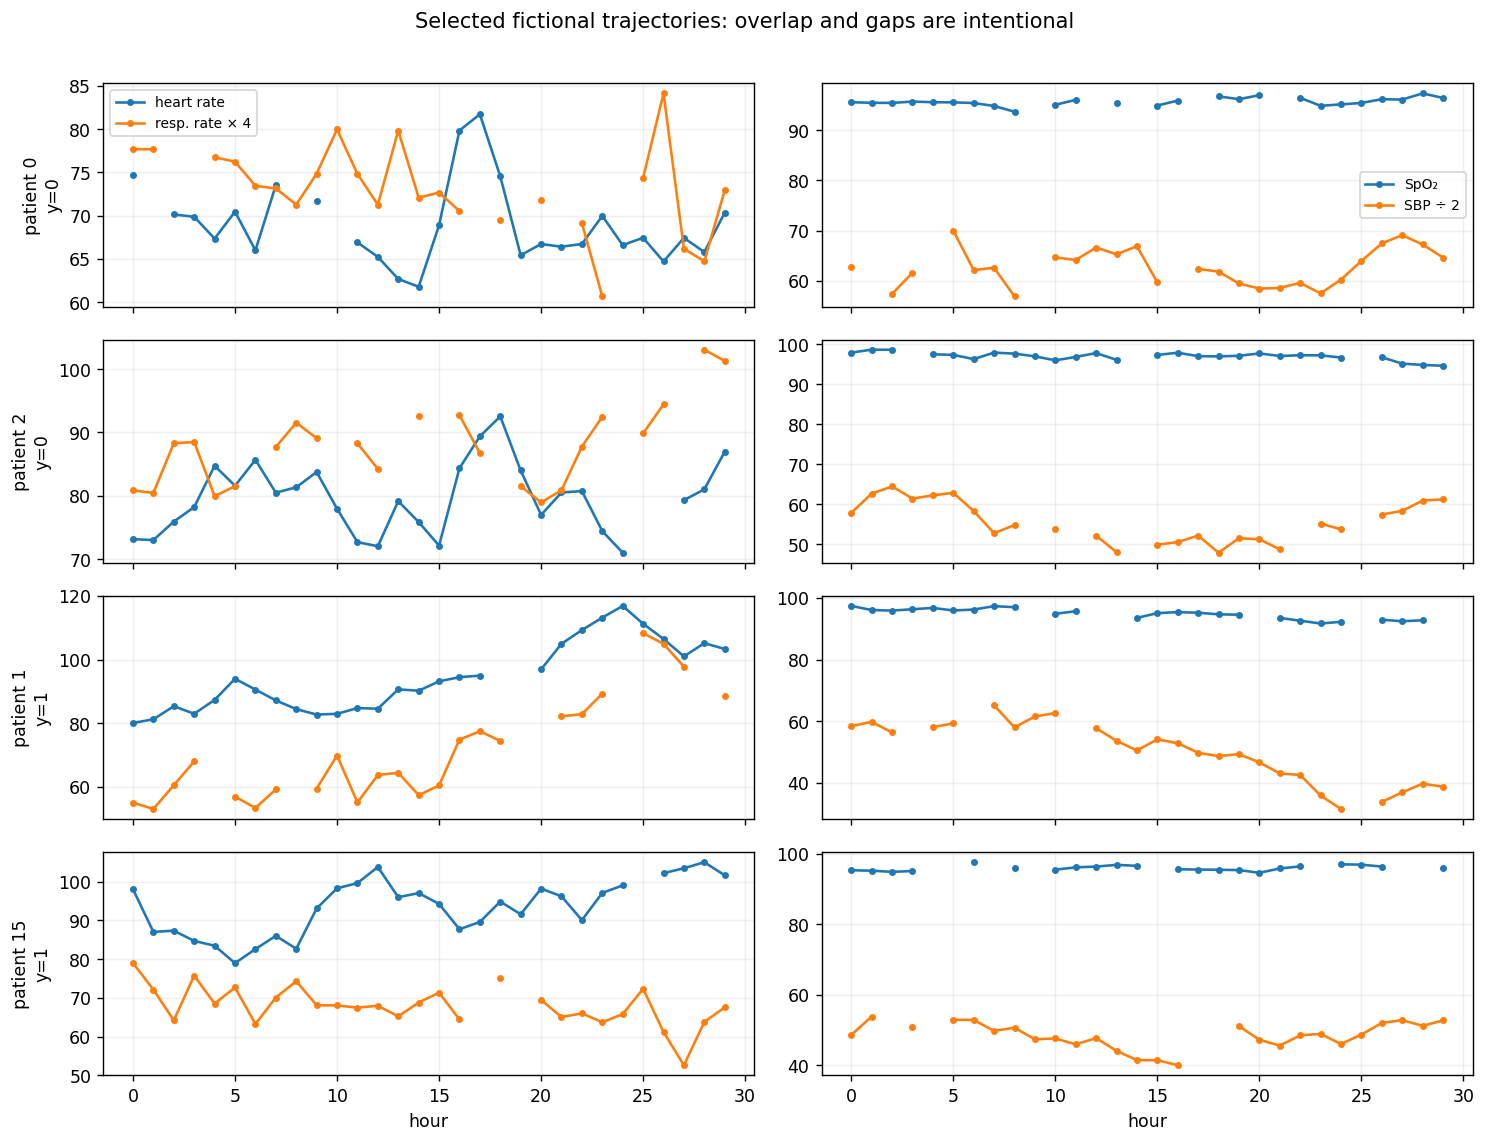

In [ ]:
negative_ids = np.flatnonzero(y == 0)[:2]
positive_ids = np.flatnonzero(y == 1)[:2]
example_ids = np.r_[negative_ids, positive_ids]

# Phase 1: plot a fixed balanced set rather than hand-picking easy cases.
fig, axes = plt.subplots(4, 2, figsize=(12, 9), sharex=True)
hours = np.arange(N_HOURS)
for row, patient_id in enumerate(example_ids):
    axes[row, 0].plot(hours, X_observed[patient_id, :, 0], "o-", markersize=3, label="heart rate")
    axes[row, 0].plot(hours, X_observed[patient_id, :, 1] * 4, "o-", markersize=3, label="resp. rate × 4")
    axes[row, 1].plot(hours, X_observed[patient_id, :, 2], "o-", markersize=3, label="SpO₂")
    axes[row, 1].plot(hours, X_observed[patient_id, :, 3] / 2, "o-", markersize=3, label="SBP ÷ 2")
    axes[row, 0].set_ylabel(f"patient {patient_id}\ny={y[patient_id]}")
    for axis in axes[row]:
        axis.grid(alpha=0.2)

axes[0, 0].legend(fontsize=8)
axes[0, 1].legend(fontsize=8)
axes[-1, 0].set_xlabel("hour")
axes[-1, 1].set_xlabel("hour")
fig.suptitle("Selected fictional trajectories: overlap and gaps are intentional", y=1.01)
plt.tight_layout()
plt.show()

# Phase 2: aggregate missingness over patients and time for each channel.
missing_by_feature = pd.Series(
    np.isnan(X_observed).mean(axis=(0, 1)), index=FEATURE_NAMES, name="missing_fraction"
)
# Phase 3: keep the table next to the trajectories it helps explain.
display(missing_by_feature.to_frame().style.format("{:.1%}"))


Visual inspection should reveal three important facts. First, neighbouring measurements are correlated. Second, event-positive and event-negative examples overlap rather than forming two obvious templates. Third, each channel has gaps. A real dataset would add irregular timestamps, medication and intervention effects, device changes, data-entry delays, censoring, and outcome uncertainty.


## 7. Split by patient before learning anything

Each simulated patient contributes one sequence, so patient-level splitting is straightforward. In real data, one person may have many admissions or overlapping windows; all records from that person must stay in one split to prevent identity leakage.

We allocate 60% to training, 20% to validation, and 20% to test, stratified by the outcome. No imputation mean, scaling statistic, model weight, epoch, or threshold is learned before this split.


In [ ]:
patient_ids = np.arange(N_PATIENTS)
# Phase 1: hold out 40% before any preprocessing statistics are learned.
train_ids, temporary_ids = train_test_split(
    patient_ids,
    test_size=0.40,
    stratify=y,
    random_state=SEED,
)
# Phase 2: divide the holdout equally into selection and final evaluation sets.
val_ids, test_ids = train_test_split(
    temporary_ids,
    test_size=0.50,
    stratify=y[temporary_ids],
    random_state=SEED + 1,
)

# Phase 3: verify sizes, prevalence, and disjoint patient membership.
split_table = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "patients": [len(train_ids), len(val_ids), len(test_ids)],
        "event_fraction": [y[train_ids].mean(), y[val_ids].mean(), y[test_ids].mean()],
    }
)
display(split_table.style.format({"event_fraction": "{:.3f}"}))

# Assertions document the most important split invariants.
assert not set(train_ids) & set(val_ids)
assert not set(train_ids) & set(test_ids)
assert not set(val_ids) & set(test_ids)


,split,patients,event_fraction
0,train,900,0.339
1,validation,300,0.340
2,test,300,0.340


## 8. Causal imputation and training-only scaling

Bidirectional interpolation can use a later measurement to fill an earlier gap. At a live prediction time, that later value may not exist. We instead:

1. carry the most recent observed value forward;
2. use a channel mean only if no earlier value exists; and
3. append an observation mask so sequence models can distinguish a measured value from a carried-forward value.

The initial channel means and all scaling statistics come from training patients only. The generator guarantees hour 0 is observed, but the mean fallback remains in the function because real data may begin with gaps.


In [ ]:
# One mean per feature, estimated without validation or test patients.
training_feature_means = np.nanmean(X_observed[train_ids], axis=(0, 1))


def causal_forward_fill(sequences, initial_values):
    '''Forward-fill [N,T,F] sequences; never use a later observation.'''
    filled = sequences.copy()

    # At hour t, replacement can use only hour t-1, which was already filled.
    for hour in range(1, filled.shape[1]):
        missing_now = np.isnan(filled[:, hour, :])
        filled[:, hour, :][missing_now] = filled[:, hour - 1, :][missing_now]

    # Fill any leading gaps with frozen training means.
    still_missing = np.isnan(filled)
    broadcast_means = np.broadcast_to(initial_values, filled.shape)
    filled[still_missing] = broadcast_means[still_missing]
    return filled


observation_mask = (~np.isnan(X_observed)).astype(np.float32)
X_filled = causal_forward_fill(X_observed, training_feature_means)

# Standardize values using only filled training trajectories.
sequence_mean = X_filled[train_ids].mean(axis=(0, 1))
sequence_sd = X_filled[train_ids].std(axis=(0, 1))
sequence_sd = np.where(sequence_sd < 1e-6, 1.0, sequence_sd)
standardized_values = (X_filled - sequence_mean) / sequence_sd

# Ten channels = five normalized values + five observed/not-observed indicators.
X_sequence = np.concatenate([standardized_values, observation_mask], axis=2).astype(np.float32)

assert not np.isnan(X_sequence).any()
print("Sequence-model input shape:", X_sequence.shape)
print("Channels =", len(FEATURE_NAMES), "values +", len(FEATURE_NAMES), "masks")


Sequence-model input shape: (1500, 30, 10)
Channels = 5 values + 5 masks


Forward filling is causal, but it is not automatically clinically correct. A value carried for 18 hours may be stale. Production features often include “time since last measurement,” validity windows, channel-specific imputation, or explicit irregular-time models. Missingness may also reflect care intensity and institutional workflow, creating fragile shortcuts when practice changes.


## 9. Build feature-based baselines before sequence models

The **last-value model** uses only the final filled value and whether it was actually observed at hour 29. It asks whether history adds anything beyond the current state.

The **summary model** uses eight features per channel: first, last, mean, standard deviation, minimum, maximum, linear slope, and recent-minus-early mean. These discard the exact order but retain level, variability, trend, and a rough recency signal.

We fit both logistic regression and histogram gradient boosting (HGB) on summaries. HGB can learn thresholds and interactions without a linear log-odds assumption. It can also overfit noisy small datasets; “nonlinear” is not synonymous with “better.”


In [ ]:
def summarize_sequences(filled_sequences):
    '''Map [patients, hours, channels] to eight summaries per channel.'''
    # Phase 1: define a shared time axis for all patient-specific slopes.
    n_patients, n_hours, n_features = filled_sequences.shape
    assert n_features == len(FEATURE_NAMES)
    time = np.arange(n_hours, dtype=float)
    centred_time = time - time.mean()
    slope_denominator = np.sum(centred_time ** 2)
    feature_blocks = []
    names = []

    # Phase 2: compute the same prespecified summaries for every channel.
    for feature_index, feature_name in enumerate(FEATURE_NAMES):
        # `values` is [patients, hours]; one row remains one patient.
        values = filled_sequences[:, :, feature_index]
        patient_mean = values.mean(axis=1, keepdims=True)

        # Closed-form least-squares slope gives one trend per patient.
        slope = np.sum((values - patient_mean) * centred_time[None, :], axis=1)
        slope /= slope_denominator

        # This block is [patients, 8]: level, spread, extremes, and trend.
        block = np.column_stack(
            [
                values[:, 0],
                values[:, -1],
                values.mean(axis=1),
                values.std(axis=1),
                values.min(axis=1),
                values.max(axis=1),
                slope,
                values[:, -6:].mean(axis=1) - values[:, :6].mean(axis=1),
            ]
        )
        feature_blocks.append(block)
        names.extend(
            [f"{feature_name}_{suffix}" for suffix in
             ["first", "last", "mean", "sd", "min", "max", "slope", "recent_minus_early"]]
        )

    # Phase 3: five [N,8] blocks become the expected [N,40] matrix.
    return np.column_stack(feature_blocks), names


X_summary, SUMMARY_NAMES = summarize_sequences(X_filled)
assert X_summary.shape == (N_PATIENTS, 8 * len(FEATURE_NAMES))

# The last-value baseline receives five values plus five observation masks.
X_last = np.concatenate(
    [X_filled[:, -1, :], observation_mask[:, -1, :]], axis=1
)
assert X_last.shape == (N_PATIENTS, 2 * len(FEATURE_NAMES))

# Establish the no-patient-information comparator before fitting any learner.
prevalence = float(y[train_ids].mean())
validation_probabilities = {"Prevalence": np.full(len(val_ids), prevalence)}
test_probabilities = {"Prevalence": np.full(len(test_ids), prevalence)}

feature_models = {
    "Last-value logistic": make_pipeline(
        StandardScaler(), LogisticRegression(C=0.4, max_iter=1_000, random_state=SEED)
    ),
    "Summary logistic": make_pipeline(
        StandardScaler(), LogisticRegression(C=0.25, max_iter=1_000, random_state=SEED)
    ),
    "Summary HGB": HistGradientBoostingClassifier(
        max_iter=120,
        max_leaf_nodes=15,
        learning_rate=0.05,
        l2_regularization=2.0,
        random_state=SEED,
    ),
}

feature_inputs = {
    "Last-value logistic": X_last,
    "Summary logistic": X_summary,
    "Summary HGB": X_summary,
}

# Fit each learner on its prespecified representation. The held-out rows
# pass through fitted models but never enter `.fit()`.
for name, model in feature_models.items():
    inputs = feature_inputs[name]
    model.fit(inputs[train_ids], y[train_ids])
    validation_probabilities[name] = model.predict_proba(inputs[val_ids])[:, 1]
    test_probabilities[name] = model.predict_proba(inputs[test_ids])[:, 1]

print("Last-value columns:", X_last.shape[1])
print("Summary columns:", X_summary.shape[1])
print("Feature-based models fitted without accessing test labels.")


Last-value columns: 10
Summary columns: 40
Feature-based models fitted without accessing test labels.


## 10. Four sequence architectures, four different assumptions

| Architecture | Main operation | Useful bias | Common limitation |
|---|---|---|---|
| Temporal CNN | filters slide over adjacent hours | detects reusable local motifs; parallel computation | receptive field depends on depth/kernel; pooling can erase timing |
| LSTM | recurrent state with input/forget/output gates | can preserve or discard information over time | sequential computation; can overfit small cohorts |
| GRU | recurrent state with update/reset gates | simpler gated recurrence than LSTM | no guarantee it preserves the clinically relevant history |
| Transformer | self-attention compares time steps | flexible long-range relationships and parallel training | data-hungry; positional information must be added |

These are not an exhaustive list. Classical autoregression, Gaussian processes, hidden Markov/state-space models, survival models, temporal point processes, GRU-D, temporal convolutional networks with dilations, and newer state-space neural networks may be better for other tasks.

The compact models below are intentionally similar in capacity. They receive identical normalized values and observation masks. The comments trace every shape change.


In [ ]:
class TemporalCNN(nn.Module):
    '''Detect local multi-channel motifs while retaining their positions.'''

    def __init__(self, input_features, n_hours=N_HOURS):
        super().__init__()
        # Phase 1: shared filters detect short motifs at every possible hour.
        self.features = nn.Sequential(
            nn.Conv1d(input_features, 24, kernel_size=5, padding=2), # [B,10,30] -> [B,24,30]
            nn.ReLU(),
            nn.Conv1d(24, 20, kernel_size=3, padding=1),            # -> [B,20,30]
            nn.ReLU(),
        )
        # Flattening retains where a motif occurred; global max pooling would erase timing.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.20),
            nn.Linear(20 * n_hours, 1),
        )

    def forward(self, sequence):
        channels_first = sequence.transpose(1, 2)  # [B,T,F] -> [B,F,T]
        return self.classifier(self.features(channels_first)).squeeze(1)


class GatedRecurrentClassifier(nn.Module):
    '''Shared wrapper for either an LSTM or GRU.'''

    def __init__(self, input_features, cell_type, hidden_size=24):
        super().__init__()
        # Phase 1: choose the gated recurrent cell while sharing the wrapper.
        recurrent_class = {"LSTM": nn.LSTM, "GRU": nn.GRU}[cell_type]
        self.recurrent = recurrent_class(
            input_size=input_features,
            hidden_size=hidden_size,
            batch_first=True,
        )
        self.classifier = nn.Sequential(nn.Dropout(0.20), nn.Linear(hidden_size, 1))

    def forward(self, sequence):
        all_hidden_states, _ = self.recurrent(sequence)  # [B,T,24]
        final_hidden_state = all_hidden_states[:, -1, :] # [B,24]
        return self.classifier(final_hidden_state).squeeze(1)


class TinyTransformer(nn.Module):
    '''Two-layer encoder with fixed sinusoidal position information.'''

    def __init__(self, input_features, n_hours=N_HOURS, model_width=24):
        super().__init__()
        # Phase 1: project the ten raw channels into the attention width.
        self.input_projection = nn.Linear(input_features, model_width)

        # Attention alone does not know order, so add a deterministic position code.
        position = torch.arange(n_hours, dtype=torch.float32)[:, None]
        divisor = torch.exp(
            torch.arange(0, model_width, 2) * (-np.log(10_000.0) / model_width)
        )
        positional_encoding = torch.zeros(n_hours, model_width)
        positional_encoding[:, 0::2] = torch.sin(position * divisor)
        positional_encoding[:, 1::2] = torch.cos(position * divisor)
        self.register_buffer("positional_encoding", positional_encoding[None, :, :])

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_width,
            nhead=4,
            dim_feedforward=48,
            dropout=0.12,
            batch_first=True,
            norm_first=False,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        # Phase 2: retain position-specific context for the fixed short window.
        # Flattening keeps position-specific information for this short fixed window.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.20),
            nn.Linear(model_width * n_hours, 1),
        )

    def forward(self, sequence):
        embedded = self.input_projection(sequence) + self.positional_encoding
        contextual = self.encoder(embedded)
        return self.classifier(contextual).squeeze(1)


INPUT_FEATURES = X_sequence.shape[2]
sequence_candidates = {
    "Temporal CNN": TemporalCNN(INPUT_FEATURES),
    "LSTM": GatedRecurrentClassifier(INPUT_FEATURES, "LSTM"),
    "GRU": GatedRecurrentClassifier(INPUT_FEATURES, "GRU"),
    "Transformer": TinyTransformer(INPUT_FEATURES),
}

# Phase 3: make capacity visible; parameter count is not treated as quality.
parameter_table = pd.DataFrame(
    {
        "model": sequence_candidates.keys(),
        "trainable_parameters": [sum(p.numel() for p in model.parameters()) for model in sequence_candidates.values()],
    }
)
display(parameter_table)


,model,trainable_parameters
0,Temporal CNN,3285
1,LSTM,3481
2,GRU,2617
3,Transformer,10729


Parameter count is not a quality ranking. The CNN's local filters, a recurrent network's compressed state, and a Transformer's pairwise attention solve different representation problems. We will judge them with the same validation and test protocol.

The diagram below summarizes data flow. The feature models compress time **before** fitting. The neural models learn a representation directly from the ordered tensor.


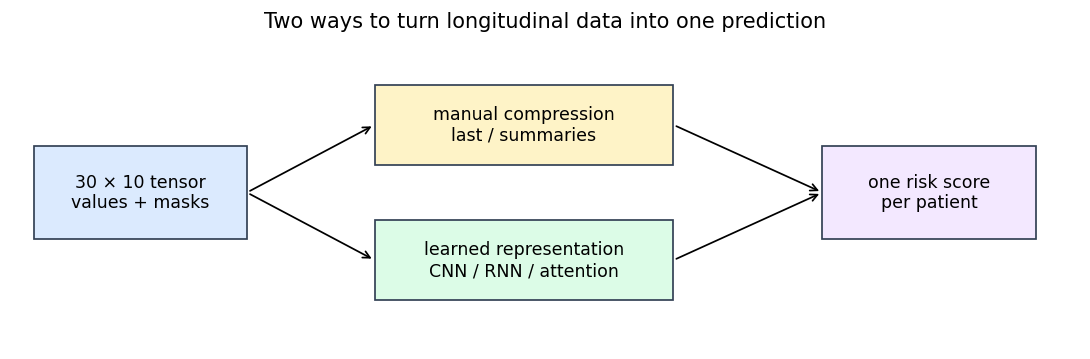

In [ ]:
# Phase 1: create the shared input and final-output boxes.
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis("off")
ax.add_patch(plt.Rectangle((0.02, 0.35), 0.20, 0.30, facecolor="#dbeafe", edgecolor="#334155"))
ax.text(0.12, 0.50, "30 × 10 tensor\nvalues + masks", ha="center", va="center")
# Phase 2: contrast manual time compression with learned representations.
branches = [
    (0.34, 0.72, "manual compression\nlast / summaries", "#fef3c7"),
    (0.34, 0.28, "learned representation\nCNN / RNN / attention", "#dcfce7"),
]
for x, y0, text, colour in branches:
    ax.add_patch(plt.Rectangle((x, y0 - 0.13), 0.28, 0.26, facecolor=colour, edgecolor="#334155"))
    ax.text(x + 0.14, y0, text, ha="center", va="center")
    ax.annotate("", xy=(x, y0), xytext=(0.22, 0.50), arrowprops={"arrowstyle": "->"})
    ax.annotate("", xy=(0.76, 0.50), xytext=(x + 0.28, y0), arrowprops={"arrowstyle": "->"})
# Phase 3: both branches produce one comparable patient-level probability.
ax.add_patch(plt.Rectangle((0.76, 0.35), 0.20, 0.30, facecolor="#f3e8ff", edgecolor="#334155"))
ax.text(0.86, 0.50, "one risk score\nper patient", ha="center", va="center")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Two ways to turn longitudinal data into one prediction")
plt.show()


## 11. Train all sequence models under one protocol

We use ordinary, **unweighted** binary cross-entropy, AdamW, gradient clipping, and early stopping on validation AUPRC. Because events make up roughly one third of the cohort, class weighting is not necessary for this demonstration. Leaving the loss unweighted also makes the neural networks' probability objective more comparable with the unweighted feature-based models.

The function never receives test IDs or test labels. It saves the state with the best validation AUPRC and restores it before returning. This makes the comparison fairer than training each architecture with a different stopping rule.


In [ ]:
# Construct one reproducibly shuffled training loader for all architectures.
# Shapes are [training patients, 30 hours, 10 channels] and [patients].
training_dataset = TensorDataset(
    torch.from_numpy(X_sequence[train_ids]),
    torch.from_numpy(y[train_ids].astype(np.float32)),
)


@torch.no_grad()
def predict_sequence_probabilities(model, sequences, batch_size=256):
    '''Run batched inference with dropout disabled and no gradient storage.'''
    model.eval()
    # Preserve [patients, hours, channels]; each model handles its own layout.
    tensor = torch.from_numpy(sequences.astype(np.float32))
    outputs = []
    for start in range(0, len(tensor), batch_size):
        # Every model returns one logit for each patient in this batch.
        batch = tensor[start : start + batch_size].to(DEVICE)
        outputs.append(torch.sigmoid(model(batch)).cpu().numpy())
    # Concatenate mini-batches back to one probability per input patient.
    return np.concatenate(outputs)


def fit_sequence_model(model, max_epochs=22, patience=5):
    '''Fit training patients; choose and restore an epoch using validation only.'''
    model = model.to(DEVICE)

    # Recreate a seeded loader so each architecture sees the same shuffle sequence.
    loader = DataLoader(
        training_dataset,
        batch_size=64,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

    # Use the same unweighted binary log-loss principle as the classical
    # probability models. The cohort is not severely imbalanced.
    loss_function = nn.BCEWithLogitsLoss()

    best_validation_auprc = -np.inf
    best_state = None
    stale_epochs = 0
    history = {"training_loss": [], "validation_auprc": []}

    for epoch in range(max_epochs):
        model.train()
        epoch_losses = []
        for batch_sequences, batch_labels in loader:
            # Batch shapes are [B,30,10] and [B]; no test tensor appears here.
            batch_sequences = batch_sequences.to(DEVICE)
            batch_labels = batch_labels.to(DEVICE)

            optimizer.zero_grad()
            logits = model(batch_sequences)  # [B,30,10] -> [B]
            loss = loss_function(logits, batch_labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()
            epoch_losses.append(float(loss.detach().cpu()))

        # AUPRC is used only to select an epoch because it emphasizes the
        # event class; final evaluation also checks AUROC and Brier score.
        val_probabilities = predict_sequence_probabilities(model, X_sequence[val_ids])
        val_auprc = average_precision_score(y[val_ids], val_probabilities)
        history["training_loss"].append(np.mean(epoch_losses))
        history["validation_auprc"].append(val_auprc)

        if val_auprc > best_validation_auprc + 1e-4:
            best_validation_auprc = val_auprc
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1

        if stale_epochs >= patience:
            break

    # `best_state` must exist because at least one epoch always runs.
    assert best_state is not None
    model.load_state_dict(best_state)
    return model, history, best_validation_auprc


In [ ]:
trained_sequence_models = {}
sequence_histories = {}

# Phase 1: apply the identical fit/early-stop helper to every architecture.
for name, candidate in sequence_candidates.items():
    fitted, history, best_val_auprc = fit_sequence_model(candidate)
    trained_sequence_models[name] = fitted
    sequence_histories[name] = history

    # Validation probabilities support threshold selection.
    validation_probabilities[name] = predict_sequence_probabilities(
        fitted, X_sequence[val_ids]
    )
    # Test probabilities are generated only after weights/epoch are frozen.
    test_probabilities[name] = predict_sequence_probabilities(
        fitted, X_sequence[test_ids]
    )
    print(
        f"{name}: {len(history['training_loss']):2d} epochs; "
        f"best validation AUPRC={best_val_auprc:.3f}"
    )
# Phase 2: all returned states are now frozen before threshold selection.


Temporal CNN:  9 epochs; best validation AUPRC=0.505
LSTM: 22 epochs; best validation AUPRC=0.491
GRU: 21 epochs; best validation AUPRC=0.497
Transformer:  8 epochs; best validation AUPRC=0.511


## 12. Diagnose optimization and overfitting

A lower training loss does not automatically mean a better clinical model. It only means the architecture is fitting the binary cross-entropy objective on training batches. Validation AUPRC can peak early or fluctuate because the cohort is modest and labels overlap.

Do not compare the numerical training losses across architectures as if they were test metrics. Use the curves to diagnose convergence and the held-out validation metric to choose an epoch.


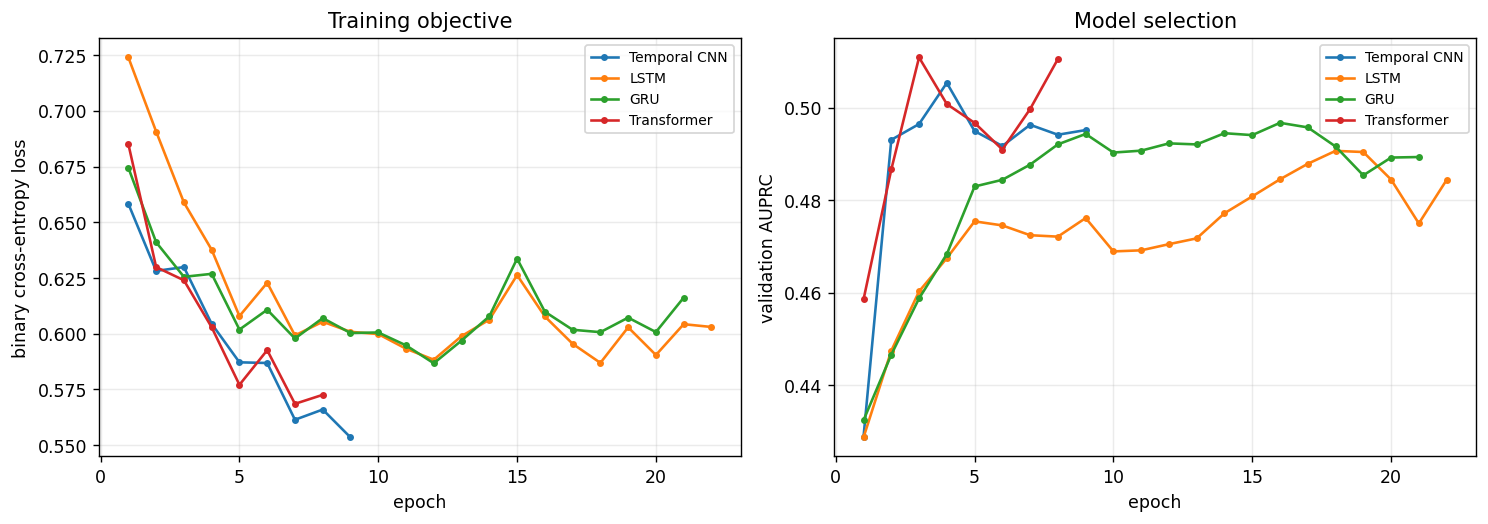

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for name, history in sequence_histories.items():
    epochs = np.arange(1, len(history["training_loss"]) + 1)
    axes[0].plot(epochs, history["training_loss"], marker="o", markersize=3, label=name)
    axes[1].plot(epochs, history["validation_auprc"], marker="o", markersize=3, label=name)

axes[0].set(title="Training objective", xlabel="epoch", ylabel="binary cross-entropy loss")
axes[1].set(title="Model selection", xlabel="epoch", ylabel="validation AUPRC")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 13. Select operating thresholds without test labels

For illustration, each model must reach at least 70% sensitivity on validation data; among qualifying thresholds, we choose the most specific. The target is intentionally lower than in a deterministic toy task because the endpoint is uncertain.

A real threshold should be justified using missed-event harm, false-alert burden, care capacity, and the intervention triggered by a score. It might vary by setting. Here it is simply a transparent teaching rule applied consistently.


In [ ]:
TARGET_SENSITIVITY = 0.70


def confusion_rates(labels, probabilities, threshold):
    # Phase 1: translate scores to binary actions at one candidate cut-point.
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if tp + fn else np.nan
    specificity = tn / (tn + fp) if tn + fp else np.nan
    return sensitivity, specificity


def choose_validation_threshold(labels, probabilities, target=TARGET_SENSITIVITY):
    '''Return the most specific threshold meeting a validation sensitivity target.'''
    # Phase 2: search validation-derived cut-points only; test labels stay hidden.
    candidates = np.unique(np.r_[0.0, probabilities, 1.0])
    feasible = []
    for threshold in candidates:
        sensitivity, specificity = confusion_rates(labels, probabilities, threshold)
        if sensitivity >= target:
            feasible.append((specificity, threshold))
    best_specificity, best_threshold = max(feasible)
    return float(best_threshold)


# Phase 3: freeze one operating threshold per model for final evaluation.
selected_thresholds = {
    name: choose_validation_threshold(y[val_ids], probabilities)
    for name, probabilities in validation_probabilities.items()
}

display(
    pd.DataFrame(
        {"model": selected_thresholds.keys(), "threshold_selected_on_validation": selected_thresholds.values()}
    ).style.format({"threshold_selected_on_validation": "{:.3f}"})
)


,model,threshold_selected_on_validation
0,Prevalence,0.339
1,Last-value logistic,0.320
2,Summary logistic,0.311
3,Summary HGB,0.246
4,Temporal CNN,0.353
5,LSTM,0.304
6,GRU,0.320
7,Transformer,0.308


## 14. Compare the ladder on the locked test patients

We now evaluate every frozen model and threshold on the test patients. AUPRC is particularly useful because prevalence is roughly one third; its uninformative reference is therefore around 0.34 rather than 0.5. AUROC retains its 0.5 reference.

We also report Brier score. All probability models use an unweighted binary classification objective, making probability quality more comparable across the ladder. A model can still have better AUPRC but worse Brier score because ranking and calibration are different properties.


,model,AUROC,AUPRC,sensitivity,specificity,PPV,Brier,validation_threshold
0,Prevalence,0.500,0.340,1.000,0.000,0.340,0.224,0.339
1,Last-value logistic,0.596,0.429,0.647,0.520,0.410,0.219,0.320
2,Summary logistic,0.638,0.472,0.637,0.571,0.433,0.214,0.311
3,Summary HGB,0.567,0.411,0.676,0.449,0.388,0.242,0.246
4,Temporal CNN,0.664,0.487,0.637,0.601,0.451,0.209,0.353
5,LSTM,0.641,0.497,0.667,0.591,0.456,0.211,0.304
6,GRU,0.628,0.490,0.686,0.556,0.443,0.213,0.320
7,Transformer,0.650,0.479,0.657,0.561,0.435,0.211,0.308


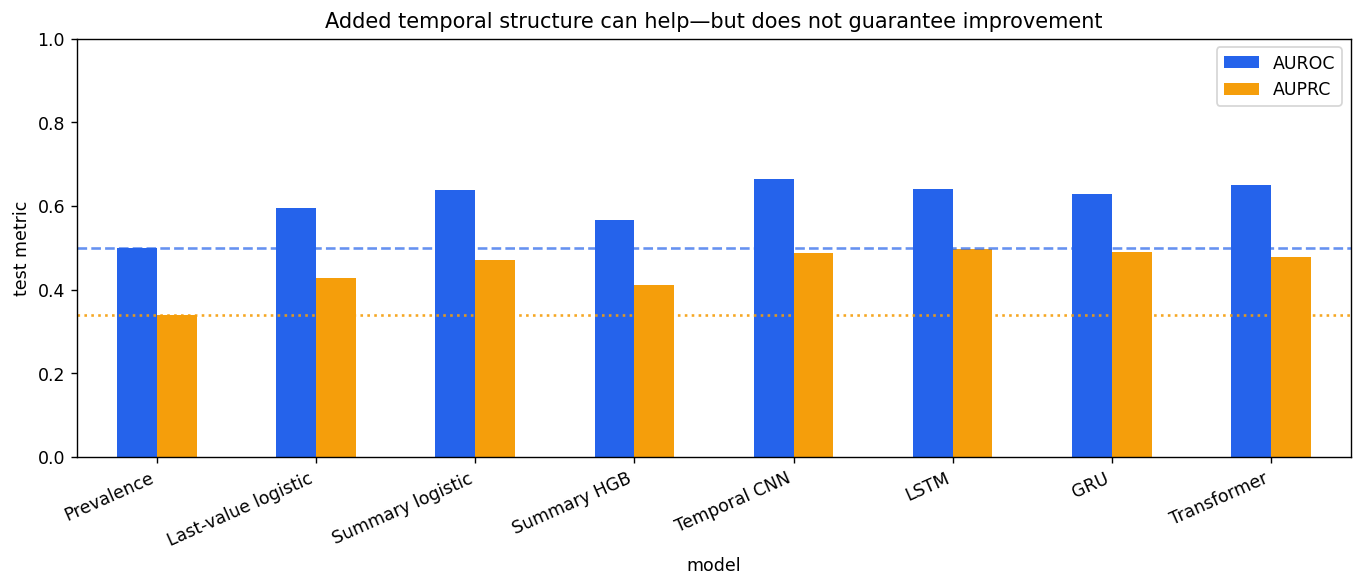

In [ ]:
def test_metric_row(name, probabilities, threshold):
    # Phase 1: apply the already-selected threshold to locked test patients.
    labels = y[test_ids]
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        "model": name,
        "AUROC": roc_auc_score(labels, probabilities),
        "AUPRC": average_precision_score(labels, probabilities),
        "sensitivity": tp / (tp + fn),
        "specificity": tn / (tn + fp),
        "PPV": tp / (tp + fp) if tp + fp else np.nan,
        "Brier": brier_score_loss(labels, probabilities),
        "validation_threshold": threshold,
    }


# Phase 2: order rows by conceptual complexity, not by achieved score.
model_order = [
    "Prevalence",
    "Last-value logistic",
    "Summary logistic",
    "Summary HGB",
    "Temporal CNN",
    "LSTM",
    "GRU",
    "Transformer",
]
# Phase 3: compute the complete test table once after all choices are frozen.
test_results = pd.DataFrame(
    [
        test_metric_row(name, test_probabilities[name], selected_thresholds[name])
        for name in model_order
    ]
)
display(test_results.style.format({column: "{:.3f}" for column in test_results.columns if column != "model"}))

# Plot rank metrics beside their no-information references.
figure_table = test_results.set_index("model")[["AUROC", "AUPRC"]]
ax = figure_table.plot.bar(figsize=(11, 4.8), color=["#2563eb", "#f59e0b"])
ax.axhline(0.5, color="#2563eb", linestyle="--", alpha=0.7)
ax.axhline(y[test_ids].mean(), color="#f59e0b", linestyle=":", alpha=0.9)
ax.set_ylim(0, 1)
ax.set_ylabel("test metric")
ax.set_title("Added temporal structure can help—but does not guarantee improvement")
plt.xticks(rotation=24, ha="right")
plt.tight_layout()
plt.show()


### How to interpret these results: evidence, not a leaderboard

In this seeded run, the ladder improves in useful but non-monotonic steps. The prevalence baseline has AUROC 0.500 and AUPRC 0.340. Last-value logistic regression reaches 0.596/0.429, and adding the whole-window summaries raises those values to 0.638/0.472. HGB is not automatically stronger: it falls to 0.567/0.411 and has the worst Brier score (0.242), consistent with an overly flexible model fitting a mostly smooth, noisy signal.

The four sequence models occupy a narrow range rather than forming a staircase. Their AUROCs range from 0.628 (GRU) to 0.664 (temporal CNN), while AUPRC ranges from 0.479 (Transformer) to 0.497 (LSTM). The temporal CNN has the best AUROC and Brier score (0.209), whereas the LSTM has the best AUPRC. Those different winners illustrate why “strongest model” is undefined until the evaluation goal is specified. None approaches perfect discrimination, and the modest gains over summary logistic regression are a more realistic teaching result than a dramatic deep-learning victory.

These are outcomes of one authored simulation and one training seed, not general rankings of CNNs, recurrent networks, and Transformers. The next section checks how much sampling uncertainty surrounds differences of only a few hundredths.


## 15. Quantify uncertainty with patient-level bootstrap intervals

Point estimates conceal sampling variation. We resample **test patients**, not individual time points, because the patient sequence is the independent evaluation unit. The interval below is a nonparametric description of this simulated test sample; it does not account for training variation, hyperparameter search, or transport to a real hospital.


In [ ]:
def bootstrap_auprc(labels, probabilities, n_resamples=300, seed=SEED):
    '''Percentile interval from patient-level bootstrap resamples.'''
    # Phase 1: resample complete patients, preserving within-sequence dependence.
    rng = np.random.default_rng(seed)
    estimates = []
    patient_positions = np.arange(len(labels))

    while len(estimates) < n_resamples:
        sample = rng.choice(patient_positions, size=len(patient_positions), replace=True)
        # Rare single-class resamples cannot define AUPRC meaningfully; skip them.
        if len(np.unique(labels[sample])) < 2:
            continue
        estimates.append(average_precision_score(labels[sample], probabilities[sample]))

    # Phase 2: report a percentile interval rather than a false exact certainty.
    return np.quantile(estimates, [0.025, 0.975])


# Phase 3: apply the identical resampling procedure to every frozen model.
uncertainty_rows = []
for name in model_order:
    low, high = bootstrap_auprc(y[test_ids], test_probabilities[name])
    point = average_precision_score(y[test_ids], test_probabilities[name])
    uncertainty_rows.append({"model": name, "AUPRC": point, "2.5%": low, "97.5%": high})

uncertainty_table = pd.DataFrame(uncertainty_rows)
display(uncertainty_table.style.format({"AUPRC": "{:.3f}", "2.5%": "{:.3f}", "97.5%": "{:.3f}"}))


,model,AUPRC,2.5%,97.5%
0,Prevalence,0.340,0.280,0.387
1,Last-value logistic,0.429,0.351,0.521
2,Summary logistic,0.472,0.377,0.571
3,Summary HGB,0.411,0.328,0.504
4,Temporal CNN,0.487,0.387,0.580
5,LSTM,0.497,0.402,0.588
6,GRU,0.490,0.394,0.588
7,Transformer,0.479,0.382,0.584


The numerical intervals overlap heavily. Summary logistic regression spans 0.377–0.571; temporal CNN, 0.387–0.580; LSTM, 0.402–0.588; GRU, 0.394–0.588; and Transformer, 0.382–0.584. These data therefore do not support a confident claim that the LSTM's AUPRC of 0.497 is better than the CNN's 0.487, or even that either is reliably better than the summary model's 0.472.

These patient-level bootstrap intervals describe only resampling of this fixed test set. Repeating the *entire* development pipeline across several seeds would add uncertainty from model fitting, while external sites and later time periods would add the larger problem of distribution shift.


## 16. Curves show the full operating trade-off

A single threshold answers one workflow question. ROC and precision–recall curves show how the trade-off changes as the threshold moves. In a low-prevalence deployment, PPV would typically be lower than in this simulated test set even if sensitivity and specificity stayed constant.


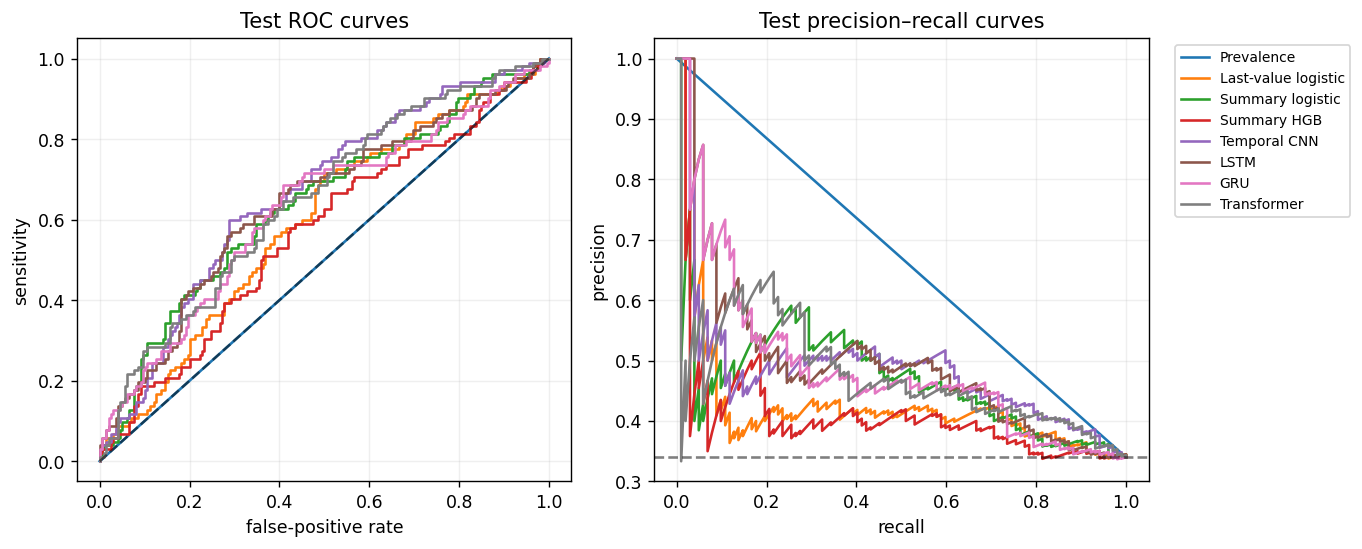

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for name in model_order:
    probabilities = test_probabilities[name]
    fpr, tpr, _ = roc_curve(y[test_ids], probabilities)
    precision, recall, _ = precision_recall_curve(y[test_ids], probabilities)
    axes[0].plot(fpr, tpr, label=name)
    axes[1].plot(recall, precision, label=name)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].axhline(y[test_ids].mean(), color="k", linestyle="--", alpha=0.5)
axes[0].set(title="Test ROC curves", xlabel="false-positive rate", ylabel="sensitivity")
axes[1].set(title="Test precision–recall curves", xlabel="recall", ylabel="precision")
for axis in axes:
    axis.grid(alpha=0.2)
axes[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## 17. Inspect one prediction without pretending it is an explanation

A trajectory plot can help a reviewer understand what information was available for a case. It does not reveal why a deep model produced its score and does not make the score clinically valid. We choose one fixed event-positive test patient and display observed values, forward-filled values, and model probabilities.


,model,predicted_probability
0,Prevalence,0.339
1,Last-value logistic,0.231
2,Summary logistic,0.179
3,Summary HGB,0.192
4,Temporal CNN,0.218
5,LSTM,0.249
6,GRU,0.267
7,Transformer,0.189


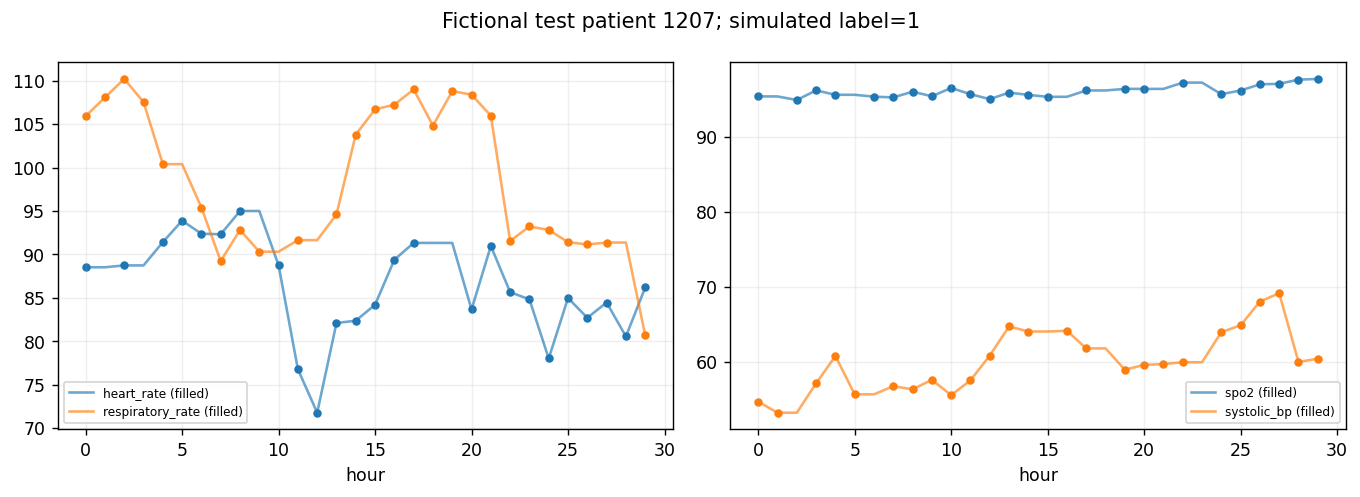

In [ ]:
example_patient = int(test_ids[np.flatnonzero(y[test_ids] == 1)[0]])
# Phase 1: select by a reproducible rule, not because the case looks persuasive.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for feature_index, feature_name in enumerate(FEATURE_NAMES[:4]):
    axis = axes[0] if feature_index < 2 else axes[1]
    scale = [1.0, 4.0, 1.0, 0.5][feature_index]
    axis.plot(
        np.arange(N_HOURS),
        X_filled[example_patient, :, feature_index] * scale,
        "-",
        alpha=0.65,
        label=f"{feature_name} (filled)",
    )
    observed_hours = np.flatnonzero(observation_mask[example_patient, :, feature_index])
    axis.scatter(
        observed_hours,
        X_observed[example_patient, observed_hours, feature_index] * scale,
        s=15,
    )
for axis in axes:
    axis.set_xlabel("hour")
    axis.grid(alpha=0.2)
    axis.legend(fontsize=7)
fig.suptitle(f"Fictional test patient {example_patient}; simulated label={y[example_patient]}")
plt.tight_layout()
plt.show()

# Phase 2: align each model's score to the same test-patient position.
case_scores = pd.DataFrame(
    {
        "model": model_order,
        "predicted_probability": [
            test_probabilities[name][np.where(test_ids == example_patient)[0][0]]
            for name in model_order
        ],
    }
)
# Phase 3: show disagreement without claiming it is formal uncertainty.
display(case_scores.style.format({"predicted_probability": "{:.3f}"}))


Differences between case scores illustrate model disagreement, not model uncertainty in a formal sense. A responsible error review would examine many prespecified cases, stratify by relevant groups and data quality, avoid altering the locked test pipeline, and test any new hypothesis on new data.


## 18. Choosing among time-series models

A model should earn its complexity. Practical considerations include:

| Situation | Reasonable starting point |
|---|---|
| Small cohort; clinicians need transparent features | penalized logistic regression on prespecified summaries |
| Important nonlinear thresholds/interactions | gradient boosting, with careful tuning and calibration |
| Short local motifs drive risk | temporal CNN or dilated TCN |
| Ordered history must be compressed into state | GRU/LSTM; consider time-aware variants for irregular sampling |
| Long-range relationships and abundant data | Transformer or state-space model, benchmarked against simpler models |
| Time-to-event and censoring matter | survival analysis rather than ordinary binary classification |
| Irregular observations carry timing information | GRU-D, time-aware RNN, point-process, or continuous-time approaches |

The strongest choice is often the simplest model that meets prespecified performance, calibration, operational, and safety requirements. Compute cost, latency, maintainability, monitoring, and the ability to explain failures matter alongside AUPRC.


## 19. What real longitudinal healthcare data would add

This simulation omits many hard problems:

**Irregular time.** “One row per hour” may be created by aggregation, which can hide exact measurement time and within-hour order.

**Informative measurement.** Clinicians order tests because of concern. A missing value can encode workflow and may change when protocols change.

**Interventions.** Fluids, oxygen, medication, and procedures alter future measurements. A model can learn treatment patterns rather than untreated physiology.

**Censoring and competing events.** Discharge, transfer, death, and loss to follow-up change who remains observable.

**Repeated windows.** Overlapping windows from one admission are correlated. Randomly splitting windows creates severe leakage.

**Site and time shift.** Devices, charting practices, patient populations, and policies vary across hospitals and years.

**Outcome validity.** Administrative codes and proxy outcomes may not represent the intended clinical event. Label adjudication and inter-rater reliability matter.

A credible study should document cohort construction, data availability at the index time, split unit, label process, missingness, interventions, subgroup coverage, calibration, uncertainty, external validation, and prospective workflow evaluation.


## 20. Knowledge check and extensions

1. Why can backward filling leak information in a live early-warning task?
2. What new information does summary logistic regression use that last-value logistic regression discards?
3. Why might the temporal CNN outperform the LSTM here? Why might that ordering reverse elsewhere?
4. Why can a model have better AUPRC but worse Brier score?
5. If two models' bootstrap intervals overlap, does that prove they are equivalent?
6. Which parts of the generator make near-perfect performance unlikely?

:::{dropdown} Optional coding extensions
- Add “time since last observation” channels and compare them with the binary mask.
- Replace the fixed 30-hour window with variable-length sequences and use padding masks.
- Remove the late motif from validation/test data to simulate temporal dataset shift.
- Repeat the entire training pipeline over five seeds and plot model-rank instability.
- Add temperature scaling using validation data, then compare test Brier score and reliability.
- Convert the endpoint to a discrete-time survival task with censoring.
:::


## 21. Take-home messages

- Define the timeline and information boundary before selecting an architecture.
- Begin with prevalence, last-value, and summary-feature models. A sequence model should demonstrate value beyond strong baselines.
- Preserve missingness information and ensure imputation is causal for the intended prediction time.
- CNNs, LSTMs, GRUs, and Transformers encode different assumptions; newer or larger does not guarantee better.
- Select epochs, hyperparameters, and thresholds on validation data—not the test set.
- Moderate, uncertain performance is more realistic than near-perfect scores. Simulated metrics remain educational and make no clinical claim.


## References

1. Harutyunyan, H., Khachatrian, H., Kale, D. C., Ver Steeg, G., & Galstyan, A. (2019). Multitask learning and benchmarking with clinical time series data. *Scientific Data, 6*, 96. <https://doi.org/10.1038/s41597-019-0103-9>
2. Che, Z., Purushotham, S., Cho, K., Sontag, D., & Liu, Y. (2018). Recurrent neural networks for multivariate time series with missing values. *Scientific Reports, 8*, 6085. <https://doi.org/10.1038/s41598-018-24271-9>
3. Bai, S., Kolter, J. Z., & Koltun, V. (2018). An empirical evaluation of generic convolutional and recurrent networks for sequence modeling. <https://arxiv.org/abs/1803.01271>
4. Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation, 9*(8), 1735–1780. <https://doi.org/10.1162/neco.1997.9.8.1735>
5. Cho, K., van Merriënboer, B., Gulcehre, C., et al. (2014). Learning phrase representations using RNN encoder–decoder for statistical machine translation. <https://arxiv.org/abs/1406.1078>
6. Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). Attention is all you need. *Advances in Neural Information Processing Systems, 30*. <https://arxiv.org/abs/1706.03762>
7. Futoma, J., Simons, M., Panch, T., Doshi-Velez, F., & Celi, L. A. (2020). The myth of generalisability in clinical research and machine learning in health care. *The Lancet Digital Health, 2*(9), e489–e492. <https://doi.org/10.1016/S2589-7500(20)30186-2>
8. Collins, G. S., Moons, K. G. M., Dhiman, P., et al. (2024). TRIPOD+AI statement. *BMJ, 385*, e078378. <https://doi.org/10.1136/bmj-2023-078378>
